In [1]:
from datetime import datetime

from pathlib import Path

import numpy as np
from scipy.stats import lognorm
import pandas as pd

from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.visualization import hist

from matplotlib import style
import matplotlib.colors as mcolors
style.use('ggplot')
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
#%matplotlib widget

In [2]:
rootdir = Path("./data")
# use find to make this csv list
with open(rootdir / "reanalyze_csvs_2026q1.txt") as f:
    csvs = f.readlines()

# loop through the csv files and read them with pandas
frames = []
for csv in csvs:
    frames.append(pd.read_csv(rootdir / csv.rstrip()))

# now concat each frame into one big frame containing all of the data
data = pd.concat(frames)

In [3]:
g = data.groupby('wfs')
g.wfs.describe()

,count,unique,top,freq
wfs,,,,
binospec,15644,1,binospec,15644
f5,680,1,f5,680
mmirs,4469,1,mmirs,4469
newf9,57,1,newf9,57


In [4]:
# re-calculate the seeing using updated spot FWHM for binospec. filter out any NaN values...
#fixed_list = []
#for wfskey, group in g:
#    wfs = wfs_systems[wfskey]
#    group = g.get_group(wfskey)
#    #group.apply(seeing, axis=1, args=(wfs,))
#    group['fixed_raw_seeing'], group['fixed_seeing'] = seeing(group, wfs)
#    fixed_list.append(group)
#fixed = pd.concat(fixed_list)
#fixed.rename(index=str, columns={"seeing": "orig_seeing", "raw seeing": "orig_raw_seeing"}, inplace=True)
#fixed.rename(index=str, columns={"fixed_seeing": "seeing", "fixed_raw_seeing": "raw seeing"}, inplace=True)
fixed = data[np.isfinite(data['seeing'])]
fixed = fixed[fixed['fwhm'] > 0.]
fixed = fixed[fixed['seeing'] > 0.]
fixed = fixed[fixed['seeing'] < 4.]
#fixed = fixed[fixed['time'] < "2020-12-31"]

In [5]:
fixed.sort_values(by='time')

,time,wfs,file,exptime,airmass,az,el,osst,outt,chamt,...,xcen,ycen,seeing,raw_seeing,vlt_seeing,raw_vlt_seeing,ellipticity,fwhm,wavefront_rms,residual_rms
0,2026-01-03T02:40:53,mmirs,mmirs_wfs_0008.fits,10.0,1.2616,151.522576,52.432529,9.3,7.40,8.00,...,188.003268,245.004697,2.015639,2.317212,1.764268,2.028232,0.101142,8.409094,3729.073809,3378.051964
1,2026-01-03T02:41:27,mmirs,mmirs_wfs_0009.fits,10.0,1.2607,151.731069,52.489467,9.3,7.41,7.94,...,186.499261,242.997191,2.129225,2.446745,1.873340,2.152701,0.138022,8.766190,2527.153421,3034.309372
2,2026-01-03T02:42:16,mmirs,mmirs_wfs_0010.fits,12.0,1.2592,152.047366,52.574879,9.2,7.41,7.94,...,189.999027,250.000468,2.315197,2.658549,2.046569,2.350083,0.089520,9.346007,2275.170746,3465.371419
3,2026-01-03T02:44:16,mmirs,mmirs_wfs_0014.fits,12.0,1.2559,152.798459,52.772826,9.1,7.46,8.00,...,190.999265,247.999150,2.196377,2.518141,1.932341,2.215423,0.121849,8.962201,3696.796779,3227.491738
4,2026-01-03T02:44:58,mmirs,mmirs_wfs_0015.fits,12.0,1.2547,153.077559,52.844677,9.1,7.47,7.94,...,190.001552,249.665317,2.181649,2.499821,1.898814,2.175737,0.120097,8.911960,2103.280447,3454.140841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2026-03-29T05:51:42,mmirs,mmirs_wfs_0080.fits,45.0,1.1360,-26.063314,61.678832,16.0,15.29,16.50,...,197.999056,235.000987,0.892181,0.963119,0.897277,0.968620,0.068564,4.587088,620.066845,1501.258245
77,2026-03-29T05:52:30,mmirs,mmirs_wfs_0081.fits,45.0,1.1368,-26.240351,61.602829,16.0,15.30,16.50,...,198.998606,234.001358,0.923779,0.997651,0.917370,0.990730,0.061911,4.684664,523.174416,1744.271668
78,2026-03-29T05:53:17,mmirs,mmirs_wfs_0082.fits,45.0,1.1376,-26.416851,61.526054,16.0,15.30,16.50,...,199.000274,234.001376,0.829036,0.895709,0.844170,0.912060,0.080340,4.397399,530.227432,1653.545325
79,2026-03-29T05:55:06,mmirs,mmirs_wfs_0084.fits,45.0,1.1395,-26.810631,61.354811,16.0,15.31,16.50,...,200.000603,236.000297,0.940117,1.016742,0.918830,0.993719,0.077304,4.738706,534.936390,1716.317170


In [6]:
# create a date-time index so we can group and analyze the data by timestamps
fixed = fixed.set_index(pd.DatetimeIndex(fixed['time'], name='ut'))

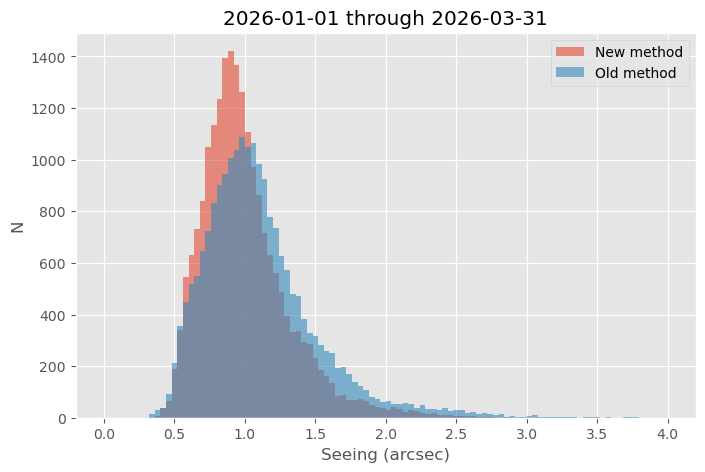

In [7]:
# make raw histogram of the zenith-corrected seeing column
fig = plt.figure(figsize=(8, 5))
plt.hist(fixed['vlt_seeing'], bins=100, range=(0.0, 4.0), alpha=0.6, label="New method")
plt.hist(fixed['seeing'], bins=100, range=(0.0, 4.0), alpha=0.6, label="Old method")
with plt.style.context('ggplot'):
    plt.title("2026-01-01 through 2026-03-31")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("N")
plt.legend()
plt.show()

In [8]:
# fit a log-normal distribution to the seeing data
sigma, loc, exp_mu = lognorm.fit(fixed['vlt_seeing'])
print(sigma, loc, exp_mu)
x = np.arange(0.0, 4.0, 0.01)
p = lognorm.pdf(x, sigma, loc=loc, scale=exp_mu)
mu = np.log(exp_mu)
mode = np.exp(mu - sigma**2) + loc
median = np.nanmedian(fixed['vlt_seeing'])
fit_median = exp_mu + loc

0.3750830184275859 0.19131751115586393 0.753527118058737


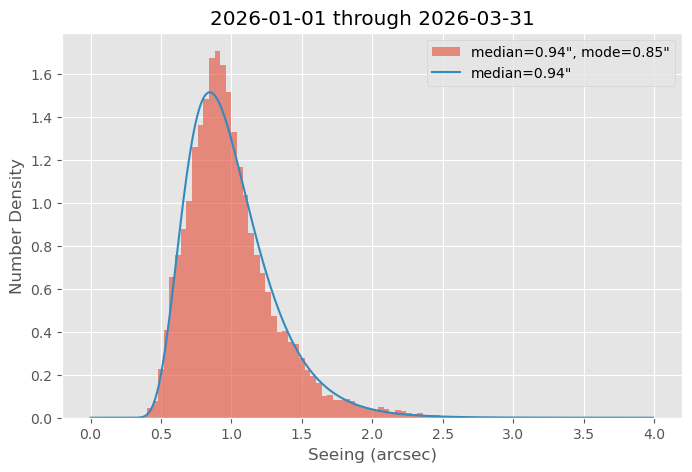

In [9]:
# plot normalized histogram with the fit and the median/mode calculated from the fit.
fig = plt.figure(figsize=(8, 5))
with plt.style.context('ggplot'):
    plt.hist(fixed['vlt_seeing'], density=True, bins=100, range=(0.0, 4.0), label="hist", alpha=0.6)
    logp = plt.plot(x, p, label="logp")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("Number Density")
    plt.title("2026-01-01 through 2026-03-31")
    plt.legend(["median=%.2f\", mode=%.2f\"" % (fit_median, mode), "median=%.2f\"" % (
        median
    )])
    plt.savefig("2026_q1.png")
plt.show()

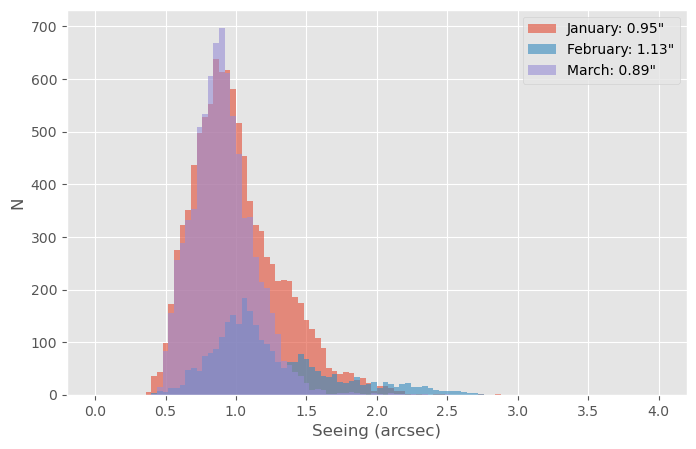

In [10]:
# panda time indexing makes it easy to group by month
fig = plt.figure(figsize=(8, 5))
months = {}
legends = []
months['January'] = fixed.loc['2026-01']
months['February'] = fixed.loc['2026-02']
months['March'] = fixed.loc['2026-03']

for m in months:
    plt.hist(months[m]['vlt_seeing'], bins=100, range=(0.0, 4.0), label=m, alpha=0.6)
    legend = "%s: %.2f\"" % (m, np.median(months[m]['vlt_seeing']))
    legends.append(legend)
plt.legend(legends)
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by month")
plt.savefig("2026_q1_monthly.png")
plt.show()

In [11]:
# now use the between_time() method to split the data into first and second halves of the night.
first_half = fixed.between_time(start_time='00:00', end_time='07:00')
second_half = fixed.between_time(start_time='07:00', end_time='14:00')
med_1st = np.median(first_half['vlt_seeing'])
med_2nd = np.median(second_half['vlt_seeing'])

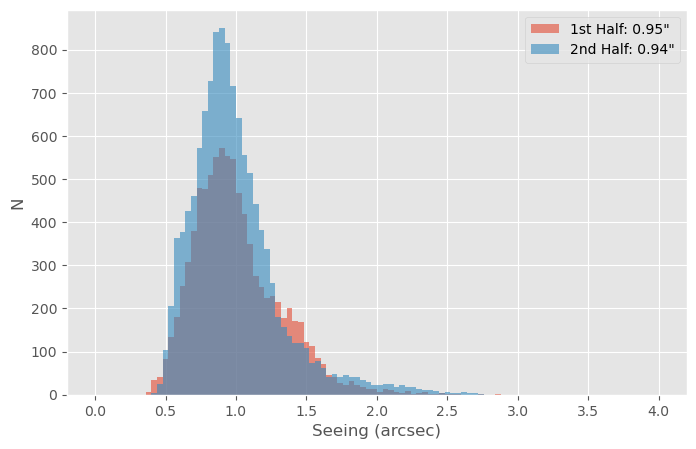

In [12]:
# plot the results and show that the seeing is better later in the night...
fig = plt.figure(figsize=(8, 5))
plt.hist(first_half['vlt_seeing'], bins=100, range=(0.0, 4.0), label="1st", alpha=0.6)
plt.hist(second_half['vlt_seeing'], bins=100, range=(0.0, 4.0), label="2nd", alpha=0.6)
plt.legend(["1st Half: %.2f\"" % med_1st, "2nd Half: %.2f\"" % med_2nd])
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by half of the night")
plt.savefig("2026_q1_1st2nd.png")
plt.show()

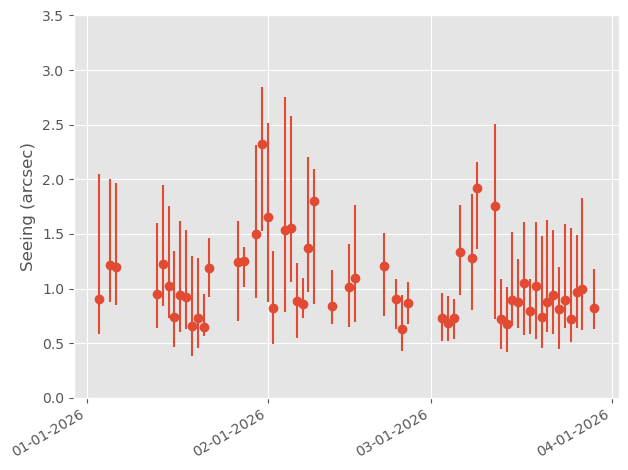

In [13]:
import matplotlib.dates as mdates

# make a new data frame that resamples the WFS data daily into the median, min, and max seeing for each day.
#fixed = fixed["2018-06-30":"2018-10-01"]
fig, ax = plt.subplots()
daily = pd.DataFrame()
daily['seeing'] = fixed.vlt_seeing.resample('D').median()
daily['max'] = fixed.vlt_seeing.resample('D').max()
daily['min'] = fixed.vlt_seeing.resample('D').min()
lowb = daily['seeing'] - daily['min']
upb = daily['max'] - daily['seeing']
plt.errorbar(daily.index, daily['seeing'], yerr=[lowb, upb], fmt='o')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
ax.set_ylim(0.0, 3.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.ylabel("Seeing (arcsec)")
#plt.title("Nightly median seeing")
plt.savefig("2026_q1_nightly.png")
plt.show()

In [14]:
date_list = list(daily.index.strftime('%Y-%m-%d'))
data = [np.array(fixed.loc[date]['vlt_seeing']) for date in date_list]
ellipticity_data = [np.array(fixed.loc[date]['ellipticity']) for date in date_list]
clean_data = {}
clean_ellipticity = {}
for d, arr in zip(date_list, data):
    if len(arr) > 0:
        clean_data[d] = arr
for d, arr in zip(date_list, ellipticity_data):
    if len(arr) > 0:
        clean_ellipticity[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m-%d").date() for d in clean_data.keys()]

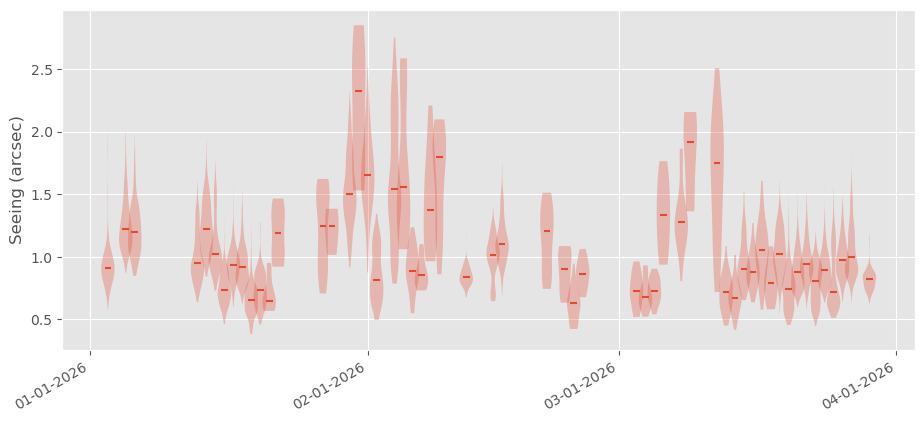

In [15]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=50, widths=1.5,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2026_q1_violin.png")
    plt.show()

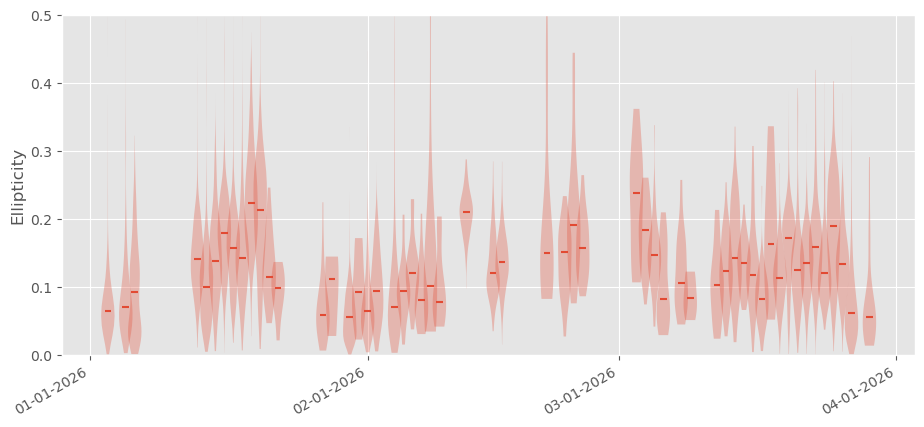

In [16]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_ellipticity.values(), mdates.date2num(date_labels), points=50, widths=1.5,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
    fig.autofmt_xdate()
    plt.ylim(0, 0.5)
    plt.ylabel("Ellipticity")
    plt.savefig("2026_q1_ellip_violin.png")
    plt.show()

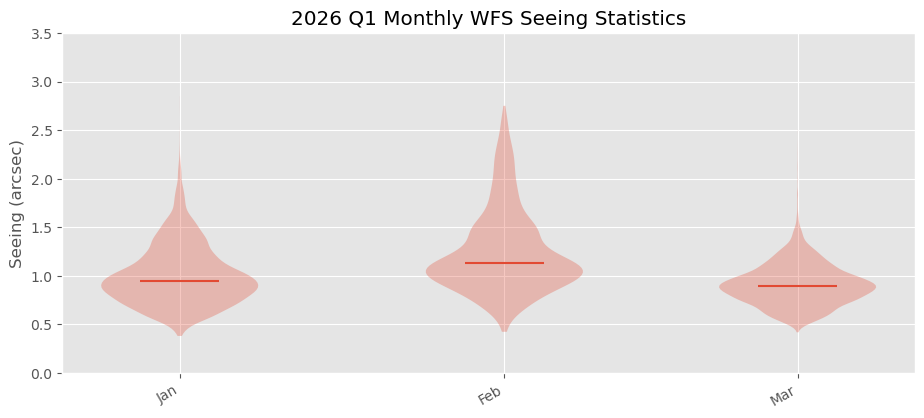

In [17]:
months = sorted(list(set(daily.index.strftime('%Y-%m'))))
mdata = [np.array(fixed.loc[month]['vlt_seeing']) for month in months]
clean_data = {}
for d, arr in zip(months, mdata):
    if len(arr) > 0:
        clean_data[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m").date() for d in clean_data.keys()]

with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=100, widths=15,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_ylim(0.0, 3.5)
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2026_q1_violin_monthly.png")
    plt.title("2026 Q1 Monthly WFS Seeing Statistics")
    plt.show()

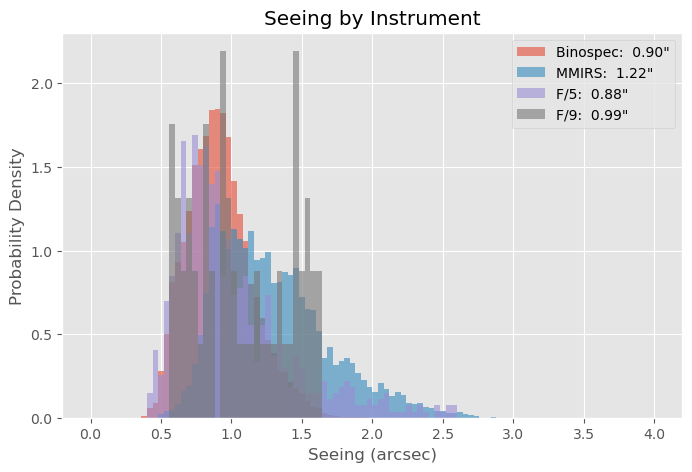

In [18]:
with plt.style.context('ggplot'):
    fig = plt.figure(figsize=(8, 5))
    medb = np.median(fixed['vlt_seeing'][fixed['wfs'] == 'binospec'])
    medm = np.median(fixed['vlt_seeing'][fixed['wfs'] == 'mmirs'])
    med5 = np.median(fixed['vlt_seeing'][fixed['wfs'] == 'f5'])
    med9 = np.median(fixed['vlt_seeing'][fixed['wfs'] == 'newf9'])
    plt.hist(fixed['vlt_seeing'][fixed['wfs'] == 'binospec'], density=True, bins=100, range=(0.0, 4.), alpha=0.6, label=f"Binospec: {medb: .2f}\"")
    plt.hist(fixed['vlt_seeing'][fixed['wfs'] == 'mmirs'], density=True, bins=100, range=(0.0, 4.), alpha=0.6, label=f"MMIRS: {medm: .2f}\"")
    plt.hist(fixed['vlt_seeing'][fixed['wfs'] == 'f5'], density=True, bins=100, range=(0.0, 4.), alpha=0.6, label=f"F/5: {med5: .2f}\"")
    plt.hist(fixed['vlt_seeing'][fixed['wfs'] == 'newf9'], density=True, bins=100, range=(0.0, 4.), alpha=0.6, label=f"F/9: {med9: .2f}\"")
    plt.legend()
    plt.title("Seeing by Instrument")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("Probability Density")
plt.savefig("per_instrument_2026_q1.png")
plt.show()

In [19]:
from minicyclop.io import read_seeing_data

In [20]:
cyclop = read_seeing_data(Path.home() / "MMT/minicyclop/data/MiniCyclop/Data/Seeing_Data.txt")

In [21]:
cyclop

,UT,flux,seeing,r0,isot,epoch_ms
ut,,,,,,
2022-06-08 03:32:32,6/8/2022 3:32:32 AM,2733.7,0.84,135.8,2022-06-08T03:32:32.968,1654659152968
2022-06-08 03:33:27,6/8/2022 3:33:27 AM,2755.7,0.84,134.4,2022-06-08T03:33:27.409,1654659207408
2022-06-08 03:34:23,6/8/2022 3:34:23 AM,2801.6,2.38,47.7,2022-06-08T03:34:23.655,1654659263655
2022-06-08 03:35:16,6/8/2022 3:35:16 AM,2853.2,1.01,112.3,2022-06-08T03:35:16.325,1654659316324
2022-06-08 03:36:00,6/8/2022 3:36:00 AM,2739.0,1.03,110.7,2022-06-08T03:36:00.691,1654659360691
...,...,...,...,...,...,...
2026-04-28 12:16:51,4/28/2026 12:16:51 PM,1450.8,1.07,105.9,2026-04-28T12:16:51.597,1777378611597
2026-04-28 12:17:37,4/28/2026 12:17:37 PM,1426.7,1.12,101.4,2026-04-28T12:17:37.260,1777378657259
2026-04-28 12:18:23,4/28/2026 12:18:23 PM,1382.1,1.11,102.7,2026-04-28T12:18:23.769,1777378703768


In [22]:
cyclop_q1 = cyclop[(cyclop.index >= '2026-01-01') & (cyclop.index < '2026-04-01')]

0.6622979808695426 0.4090506043400215 0.6859139134463262


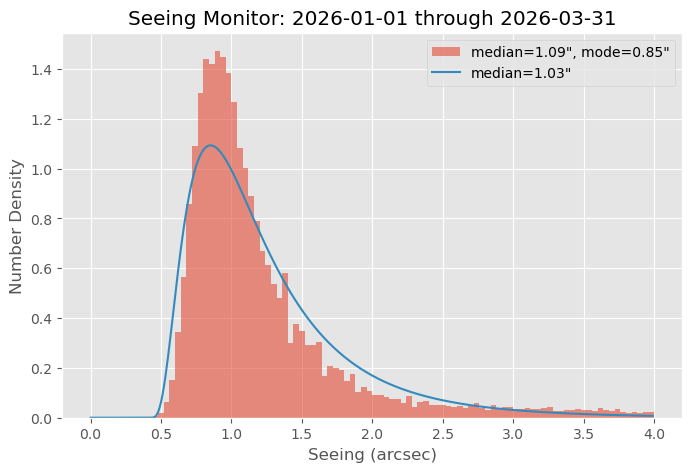

In [23]:
# fit a log-normal distribution to the seeing data
sigma, loc, exp_mu = lognorm.fit(cyclop_q1['seeing'])
print(sigma, loc, exp_mu)
x = np.arange(0.0, 4.0, 0.01)
p = lognorm.pdf(x, sigma, loc=loc, scale=exp_mu)
mu = np.log(exp_mu)
mode = np.exp(mu - sigma**2) + loc
median = np.nanmedian(cyclop_q1['seeing'])
fit_median = exp_mu + loc

# plot normalized histogram with the fit and the median/mode calculated from the fit.
fig = plt.figure(figsize=(8, 5))
with plt.style.context('ggplot'):
    plt.hist(cyclop_q1['seeing'], density=True, bins=100, range=(0.0, 4.0), label="hist", alpha=0.6)
    logp = plt.plot(x, p, label="logp")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("Number Density")
    plt.title("Seeing Monitor: 2026-01-01 through 2026-03-31")
    plt.legend(["median=%.2f\", mode=%.2f\"" % (fit_median, mode), "median=%.2f\"" % (
        median
    )])
    plt.savefig("2026_q1_cyclop_hist.png")
plt.show()

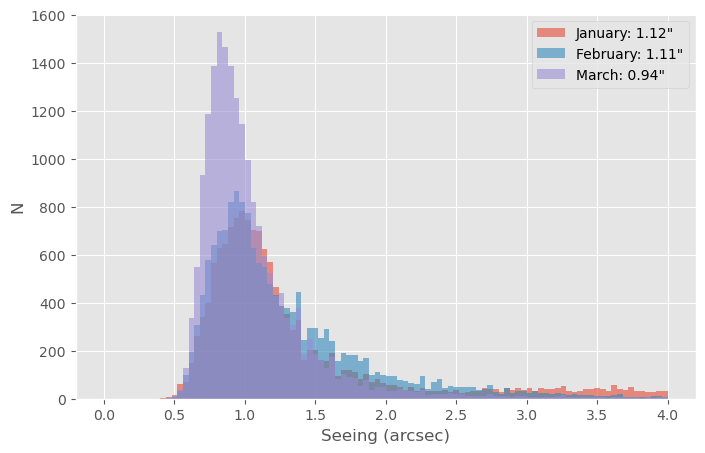

In [24]:
# panda time indexing makes it easy to group by month
fig = plt.figure(figsize=(8, 5))
cyc_months = {}
legends = []
cyc_months['January'] = cyclop_q1.loc['2026-01']
cyc_months['February'] = cyclop_q1.loc['2026-02']
cyc_months['March'] = cyclop_q1.loc['2026-03']

for m in cyc_months.keys():
    plt.hist(cyc_months[m]['seeing'], bins=100, range=(0.0, 4.0), label=m, alpha=0.6)
    legend = "%s: %.2f\"" % (m, np.median(cyc_months[m]['seeing']))
    legends.append(legend)
plt.legend(legends)
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by month")
plt.savefig("2026_q1_cyclop_monthly.png")
plt.show()

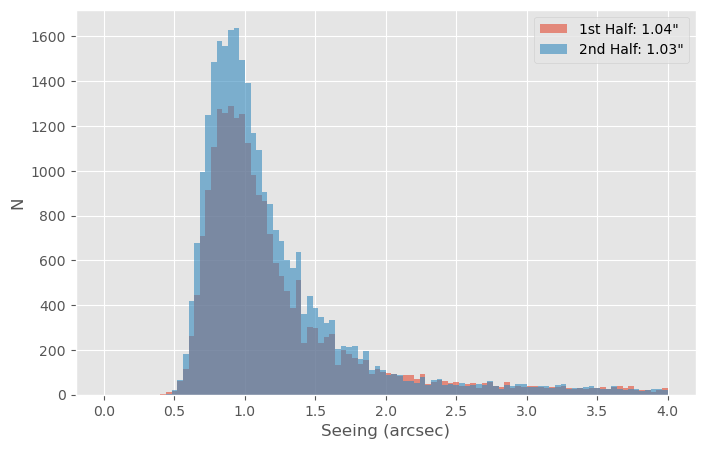

In [25]:
# now use the between_time() method to split the data into first and second halves of the night.
first_half = cyclop_q1.between_time(start_time='00:00', end_time='07:00')
second_half = cyclop_q1.between_time(start_time='07:00', end_time='14:00')
med_1st = np.median(first_half['seeing'])
med_2nd = np.median(second_half['seeing'])

# plot the results and show that the seeing is better later in the night...
fig = plt.figure(figsize=(8, 5))
plt.hist(first_half['seeing'], bins=100, range=(0.0, 4.0), label="1st", alpha=0.6)
plt.hist(second_half['seeing'], bins=100, range=(0.0, 4.0), label="2nd", alpha=0.6)
plt.legend(["1st Half: %.2f\"" % med_1st, "2nd Half: %.2f\"" % med_2nd])
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by half of the night")
plt.savefig("2026_q1_cyclop_1st2nd.png")
plt.show()

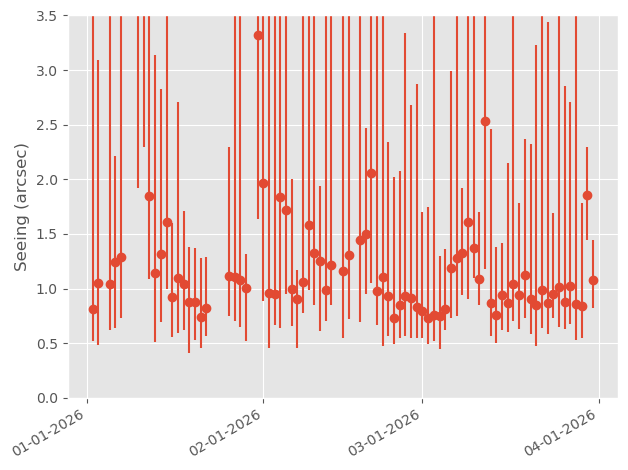

In [26]:
# make a new data frame that resamples the WFS data daily into the median, min, and max seeing for each day.
#fixed = fixed["2018-06-30":"2018-10-01"]
fig, ax = plt.subplots()
daily = pd.DataFrame()
daily['seeing'] = cyclop_q1.seeing.resample('D').median()
daily['max'] = cyclop_q1.seeing.resample('D').max()
daily['min'] = cyclop_q1.seeing.resample('D').min()
lowb = daily['seeing'] - daily['min']
upb = daily['max'] - daily['seeing']
plt.errorbar(daily.index, daily['seeing'], yerr=[lowb, upb], fmt='o')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
ax.set_ylim(0.0, 3.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.ylabel("Seeing (arcsec)")
#plt.title("Nightly median seeing")
plt.savefig("2026_q1_cyclop_plot_monthly.png")
plt.show()

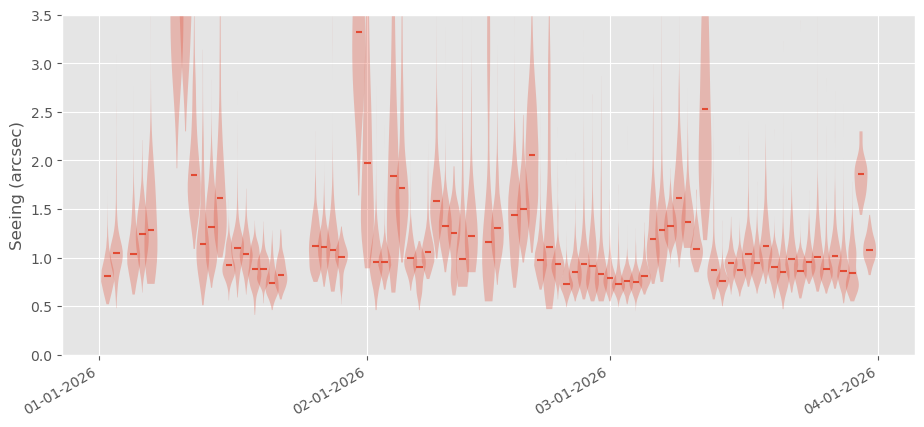

In [27]:
date_list = list(daily.index.strftime('%Y-%m-%d'))
data = [np.array(cyclop_q1.loc[date]['seeing']) for date in date_list]

clean_data = {}
for d, arr in zip(date_list, data):
    if len(arr) > 0:
        clean_data[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m-%d").date() for d in clean_data.keys()]

with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=50, widths=1.5,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
    ax.set_ylim(0.0, 3.5)
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2026_q1_cyclop_violin.png")
    plt.show()

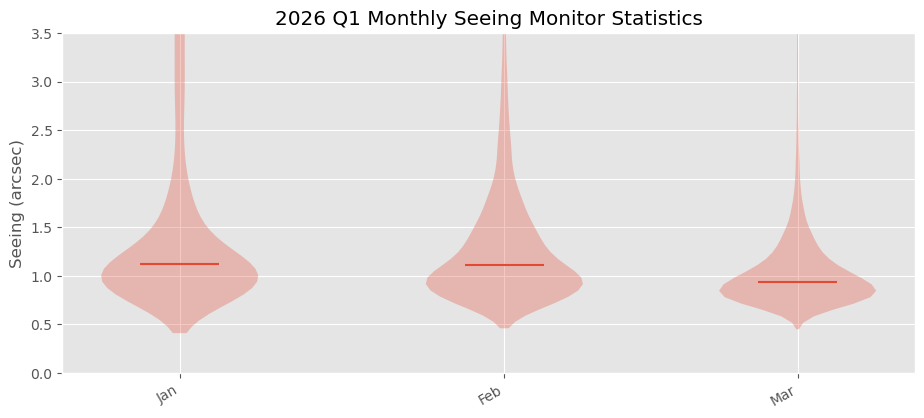

In [28]:
months = sorted(list(set(daily.index.strftime('%Y-%m'))))
mdata = [np.array(cyclop_q1.loc[month]['seeing']) for month in months]
clean_data = {}
for d, arr in zip(months, mdata):
    if len(arr) > 0:
        clean_data[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m").date() for d in clean_data.keys()]

with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=100, widths=15,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_ylim(0.0, 3.5)
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2026_q1_cyclop_violin_monthly.png")
    plt.title("2026 Q1 Monthly Seeing Monitor Statistics")
    plt.show()

In [29]:
bino = fixed[fixed['wfs'] == 'binospec']
mmirs = fixed[fixed['wfs'] == 'mmirs']
f5 = fixed[fixed['wfs'] == 'f5']
f9 = fixed[fixed['wfs'] == 'newf9']

In [30]:
bino_dates = sorted(list(set(bino.index.strftime('%Y-%m-%d'))))
mmirs_dates = sorted(list(set(mmirs.index.strftime('%Y-%m-%d'))))
f5_dates = sorted(list(set(f5.index.strftime('%Y-%m-%d'))))
f9_dates = sorted(list(set(f9.index.strftime('%Y-%m-%d'))))
bino_dates, mmirs_dates, f5_dates, f9_dates

(['2026-01-13',
  '2026-01-14',
  '2026-01-15',
  '2026-01-16',
  '2026-01-17',
  '2026-01-18',
  '2026-01-19',
  '2026-01-20',
  '2026-02-12',
  '2026-02-15',
  '2026-02-16',
  '2026-03-19',
  '2026-03-20',
  '2026-03-21',
  '2026-03-22',
  '2026-03-23',
  '2026-03-24',
  '2026-03-25',
  '2026-03-26'],
 ['2026-01-03',
  '2026-01-05',
  '2026-01-06',
  '2026-01-28',
  '2026-01-30',
  '2026-01-31',
  '2026-02-01',
  '2026-02-02',
  '2026-02-04',
  '2026-03-27',
  '2026-03-29'],
 ['2026-02-05',
  '2026-02-06',
  '2026-02-07',
  '2026-02-08',
  '2026-02-09',
  '2026-02-21',
  '2026-02-23',
  '2026-02-24',
  '2026-02-25',
  '2026-03-03',
  '2026-03-04',
  '2026-03-05',
  '2026-03-06',
  '2026-03-08',
  '2026-03-09',
  '2026-03-12',
  '2026-03-13',
  '2026-03-14',
  '2026-03-15',
  '2026-03-16',
  '2026-03-17',
  '2026-03-18'],
 ['2026-01-21', '2026-01-22', '2026-01-27'])

In [31]:
cyc_bino = np.hstack([np.array(cyclop_q1.loc[date]['seeing']) for date in bino_dates])
cyc_mmirs = np.hstack([np.array(cyclop_q1.loc[date]['seeing']) for date in mmirs_dates])
cyc_f5 = np.hstack([np.array(cyclop_q1.loc[date]['seeing']) for date in f5_dates])
cyc_f9 = np.hstack([np.array(cyclop_q1.loc[date]['seeing']) for date in f9_dates])

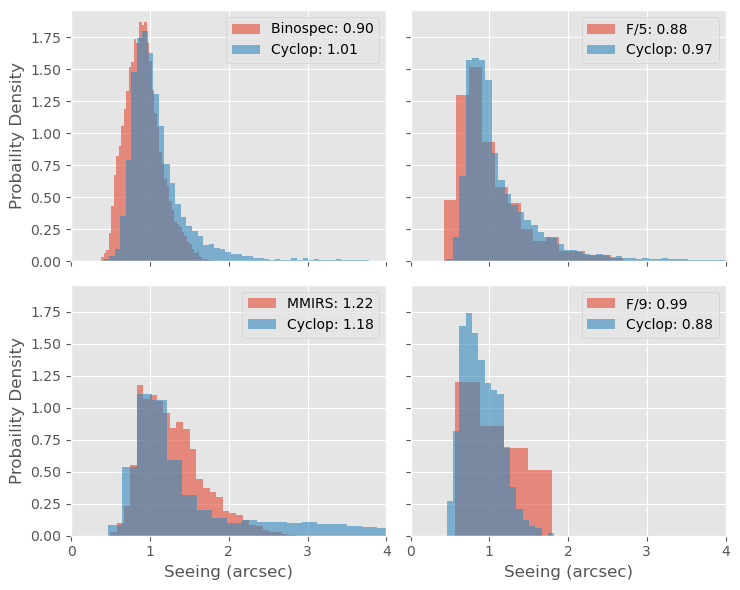

In [33]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(2, 2, figsize=(7.5, 6), sharex=True, sharey=True)
    ax = ax.flat
    fig.subplots_adjust(hspace=0)

    hist(bino['vlt_seeing'], bins='scott', ax=ax[0], histtype='stepfilled', alpha=0.6, density=True)
    hist(cyc_bino, bins='scott', ax=ax[0], histtype='stepfilled', alpha=0.6, density=True)
    ax[0].legend([f"Binospec: {np.median(bino['vlt_seeing']):.2f}", f"Cyclop: {np.median(cyc_bino):.2f}"])
    ax[0].set_ylabel("Probaility Density")
    ax[0].set_xlim(0, 4)

    hist(f5['vlt_seeing'], bins='scott', ax=ax[1], histtype='stepfilled', alpha=0.6, density=True)
    hist(cyc_f5, bins='scott', ax=ax[1], histtype='stepfilled', alpha=0.6, density=True)
    ax[1].legend([f"F/5: {np.median(f5['vlt_seeing']):.2f}", f"Cyclop: {np.median(cyc_f5):.2f}"])
    ax[1].set_xlim(0, 4)

    hist(mmirs['vlt_seeing'], bins='scott', ax=ax[2], histtype='stepfilled', alpha=0.6, density=True)
    hist(cyc_mmirs, bins='scott', ax=ax[2], histtype='stepfilled', alpha=0.6, density=True)
    ax[2].legend([f"MMIRS: {np.median(mmirs['vlt_seeing']):.2f}", f"Cyclop: {np.median(cyc_mmirs):.2f}"])
    ax[2].set_xlim(0, 4)
    ax[2].set_xlabel("Seeing (arcsec)")
    ax[2].set_ylabel("Probaility Density")

    hist(f9['vlt_seeing'], bins='scott', ax=ax[3], histtype='stepfilled', alpha=0.6, density=True)
    hist(cyc_f9, bins='scott', ax=ax[3], histtype='stepfilled', alpha=0.6, density=True)
    ax[3].legend([f"F/9: {np.median(f9['vlt_seeing']):.2f}", f"Cyclop: {np.median(cyc_f9):.2f}"])
    ax[3].set_xlim(0, 4)
    ax[3].set_xlabel("Seeing (arcsec)")


    plt.tight_layout()
    plt.savefig("2026_q1_cyclop_vs_inst.png")
    plt.show()

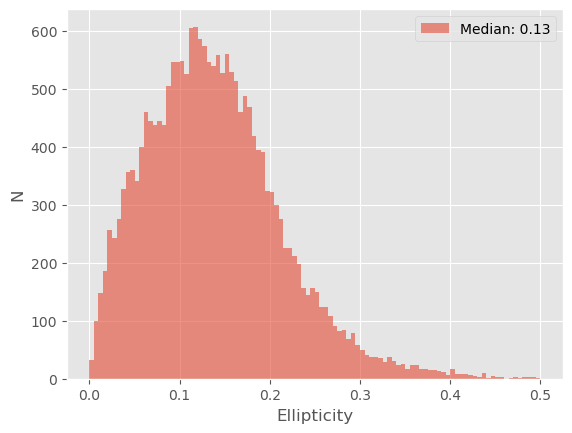

In [34]:
plt.hist(fixed['ellipticity'], bins=100, range=(0.0, 0.5), alpha=0.6, label=f"Median: {np.median(fixed['ellipticity']):.2f}")
plt.xlabel("Ellipticity")
plt.ylabel("N")
plt.legend()
plt.savefig("ellipticity_2026_q1.png")
plt.show()

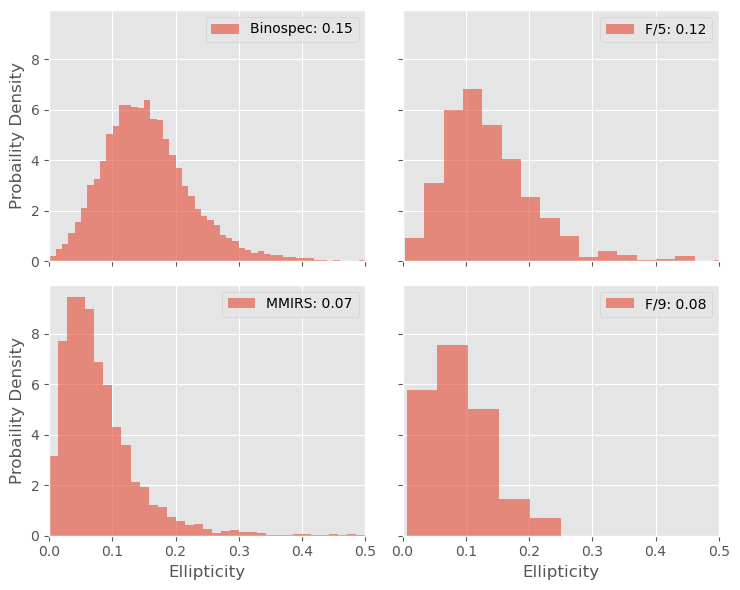

In [35]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(2, 2, figsize=(7.5, 6), sharex=True, sharey=True)
    ax = ax.flat
    fig.subplots_adjust(hspace=0)

    hist(bino['ellipticity'], bins='scott', ax=ax[0], histtype='stepfilled', alpha=0.6, density=True)
    ax[0].legend([f"Binospec: {np.median(bino['ellipticity']):.2f}"])
    ax[0].set_ylabel("Probaility Density")
    ax[0].set_xlim(0, .5)

    hist(f5['ellipticity'], bins='scott', ax=ax[1], histtype='stepfilled', alpha=0.6, density=True)
    ax[1].legend([f"F/5: {np.median(f5['ellipticity']):.2f}"])
    ax[1].set_xlim(0, .5)

    hist(mmirs['ellipticity'], bins='scott', ax=ax[2], histtype='stepfilled', alpha=0.6, density=True)
    ax[2].legend([f"MMIRS: {np.median(mmirs['ellipticity']):.2f}"])
    ax[2].set_xlim(0, .5)
    ax[2].set_xlabel("Ellipticity")
    ax[2].set_ylabel("Probaility Density")

    hist(f9['ellipticity'], bins='scott', ax=ax[3], histtype='stepfilled', alpha=0.6, density=True)
    ax[3].legend([f"F/9: {np.median(f9['ellipticity']):.2f}"])
    ax[3].set_xlim(0, .5)
    ax[3].set_xlabel("Ellipticity")


    plt.tight_layout()
    plt.savefig("2026_q1_ellip_vs_inst.png")
    plt.show()

/Users/tim/conda/envs/mmtwfs/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/tim/conda/envs/mmtwfs/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


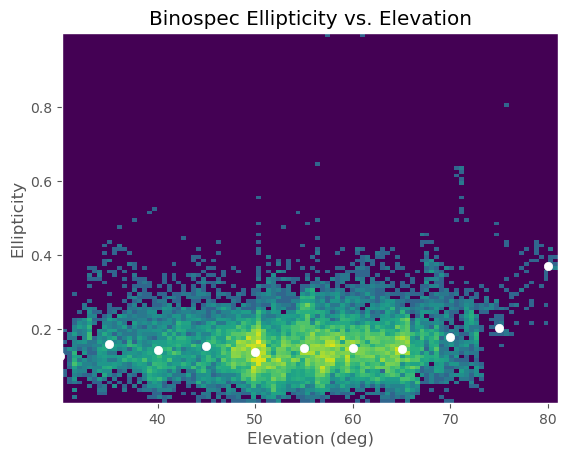

In [36]:
els = [30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
e_meds = []
for el in els:
    slice = bino[(bino['el'] >= el-2.5) & (bino['el'] <= el+2.5)]
    e_meds.append(np.median(slice['ellipticity']))

with plt.style.context('ggplot', after_reset=True):
    plt.hist2d(bino['el'], bino['ellipticity'], bins=100, cmap='viridis', norm=mcolors.PowerNorm(0.3))
    plt.scatter(els, e_meds, color='w')
    plt.xlabel("Elevation (deg)")
    plt.ylabel("Ellipticity")
    plt.title("Binospec Ellipticity vs. Elevation")
    plt.savefig("2026q1_bino_ellip_vs_el.png")
    plt.show()